<a href="https://colab.research.google.com/github/1021114Carlos/finance_app/blob/main/TargetDateSavings_RealReturn_calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Target Amount to Save (e.g., 100K, 1M): 500000
Number of Years (e.g., 10): 25

Phase 1: To reach $500,000 in 25.0 years, your Monthly Savings is: $1,666.6667

Phase 2: Cost of Investing 1666.6667 in a Passive ETF. Enter percentages as integers.
Annual Gross Market Return % (e.g., 7): 7
Annual Inflation % (e.g., 3): 3
Annual Expense Ratio % (e.g., 3): 3
Annual Turnover Rate % (e.g., 2): 3


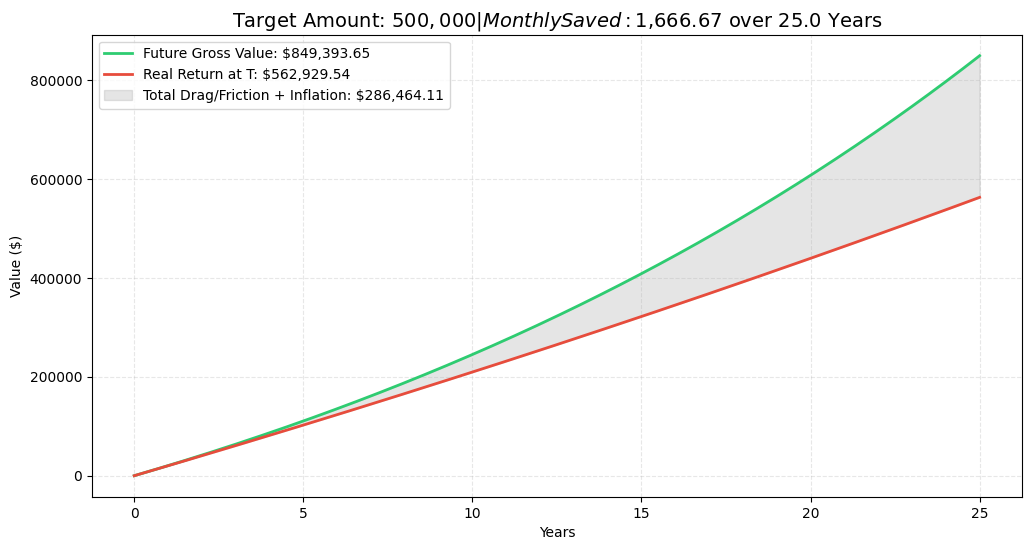


--- RESULTS AT TIME T (25.0 YEARS) ---
Monthly Savings:             $1,666.67
Future Gross Value:          $849,393.65
Real Return:                 $562,929.54
Total Drag/Friction + Inf:   $286,464.11


In [ ]:
def run_etf_strategy():
    # STEP 1: CALCULATE THE RAW MONTHLY SAVINGS (y)
    X = float(input("Target Amount to Save (e.g., 100K, 1M): "))
    T = float(input("Number of Years (e.g., 10): "))

    total_months = int(T * 12)
    # y is the simple monthly amount to reach X over T years (no interest assumed yet)
    y = X / total_months

    print(f"\nPhase 1: To reach ${X:,.0f} in {T} years, your Monthly Savings is: ${y:,.4f}")

    # --- STEP 2: INVEST (y) IN A PASSIVE ETF
    # User enters percentages as integers
    print(f"\nPhase 2: Cost of Investing {y:.4f} in a Passive ETF. Enter percentages as integers.")
    gross_return_int = float(input("Annual Gross Market Return % (e.g., 7): "))
    inflation_int = float(input("Annual Inflation % (e.g., 3): "))
    expense_ratio_int = float(input("Annual Expense Ratio % (e.g., 3): "))
    turnover_int = float(input("Annual Turnover Rate % (e.g., 2): "))

    # Convert to decimals
    r_gross = gross_return_int / 100
    inf = inflation_int / 100
    exp = expense_ratio_int / 100
    turn = turnover_int / 100

    # Internal friction (0.41% per 100% turnover)
    fric = turn * 0.0041
    total_drag_rate = inf + exp + fric

    # STEP 3: SIMULATE PERFORMANCE AT TIME T
    months = np.arange(total_months + 1)

    # Rates for simulation
    monthly_nominal_rate = (1 + (r_gross - exp - fric))**(1/12) - 1
    # Real Rate = ((1 + Gross) / (1 + Total Drags)) - 1
    annual_real_rate = ((1 + r_gross) / (1 + total_drag_rate)) - 1
    monthly_real_rate = (1 + annual_real_rate)**(1/12) - 1

    gross_bal = [0.0]
    real_bal = [0.0]

    for m in range(1, total_months + 1):
        # Future Value of y (Green Line)
        gross_bal.append((gross_bal[-1] + y) * (1 + monthly_nominal_rate))
        # Real Return of y (Red Line)
        real_bal.append((real_bal[-1] + y) * (1 + monthly_real_rate))

    # Values at Time T
    final_gross = gross_bal[-1]
    final_real = real_bal[-1]
    total_drag_value = final_gross - final_real

    # --- STEP 4: VISUALIZE ---
    plt.figure(figsize=(12, 6))
    plt.plot(months/12, gross_bal, label=f'Future Gross Value: ${final_gross:,.2f}', color='#2ecc71', lw=2)
    plt.plot(months/12, real_bal, label=f'Real Return at T: ${final_real:,.2f}', color='#e74c3c', lw=2)
    plt.fill_between(months/12, real_bal, gross_bal, color='gray', alpha=0.2, label=f'Total Drag/Friction + Inflation: ${total_drag_value:,.2f}')

    plt.title(f"Target Amount: ${X:,.0f}| Monthly  Saved: ${y:,.2f} over {T} Years", fontsize=14)
    plt.xlabel("Years")
    plt.ylabel("Value ($)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    print(f"\n--- RESULTS AT TIME T ({T} YEARS) ---")
    print(f"Monthly Savings:             ${y:,.2f}")
    print(f"Future Gross Value:          ${final_gross:,.2f}")
    print(f"Real Return:                 ${final_real:,.2f}")
    print(f"Total Drag/Friction + Inf:   ${total_drag_value:,.2f}")

# Execute
run_etf_strategy()


Target Amount (Real Purchasing Power)

Target Amount in today's buying power: 500000
Number of Years : 25
Expected Annual Gross Return % (e.g., 7): 7
Annual Inflation % (e.g., 3): 3
ETF Expense Ratio % (e.g., 3): 3
ETF Turnover Rate % (e.g., 2): 3


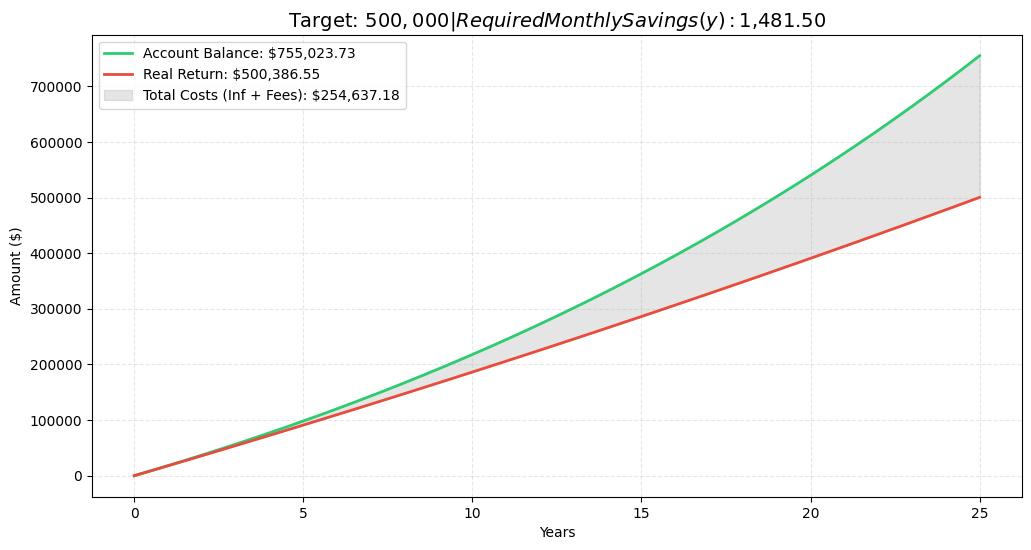

RESULTS AT YEAR 25.0
Required Monthly Savings:      $1,481.50
Future Gross Value:            $755,023.73
Real Return (Purchasing Power):$500,386.55 (Target reached!)
Total Value Lost to Drags:     $254,637.18


In [ ]:
def run_real_goal_planner():
    # --- 1. USER INPUTS ---
    X = float(input("Target Amount in today's buying power: "))
    T = float(input("Number of Years : "))

    # Percentages as integers
    r_gross_int = float(input("Expected Annual Gross Return % (e.g., 7): "))
    inf_int = float(input("Annual Inflation % (e.g., 3): "))
    exp_int = float(input("ETF Expense Ratio % (e.g., 3): "))
    turn_int = float(input("ETF Turnover Rate % (e.g., 2): "))

    # --- 2. CONVERT TO DECIMALS & CALCULATE REAL RATE ---
    r_gross = r_gross_int / 100
    inf = inf_int / 100
    exp = exp_int / 100
    turn = turn_int / 100

    # Internal friction (0.41% per 100% turnover)
    fric = turn * 0.0041
    total_drag_rate = inf + exp + fric

    # Real Annual Rate = ((1 + Gross) / (1 + Total Drags)) - 1
    annual_real_rate = ((1 + r_gross) / (1 + total_drag_rate)) - 1
    monthly_real_rate = (1 + annual_real_rate)**(1/12) - 1
    total_months = int(T * 12)

    # CALCULATE REQUIRED MONTHLY SAVINGS (y)
    if monthly_real_rate == 0:
        y = X / total_months
    else:
        y = (X * monthly_real_rate) / ((1 + monthly_real_rate)**total_months - 1)

    # SIMULATE AT TIME T
    months = np.arange(total_months + 1)

    # Net Nominal Rate (What shows on the statement: Gross minus fund fees)
    net_nominal_annual = r_gross - exp - fric
    monthly_nominal_rate = (1 + net_nominal_annual)**(1/12) - 1

    gross_bal = [0.0]
    real_bal = [0.0]

    for m in range(1, total_months + 1):
        # Gross Balance: Future Value of monthly savings y
        gross_bal.append((gross_bal[-1] + y) * (1 + monthly_nominal_rate))
        # Real Balance: Actual value of y after inflation and frictions
        real_bal.append((real_bal[-1] + y) * (1 + monthly_real_rate))

    # RESULTS AT TIME T
    final_gross = gross_bal[-1]
    final_real = real_bal[-1] # This will equal your Target X
    total_costs_at_T = final_gross - final_real

    # VISUALIZE
    plt.figure(figsize=(12, 6))
    plt.plot(months/12, gross_bal, label=f'Account Balance: ${final_gross:,.2f}', color='#2ecc71', lw=2)
    plt.plot(months/12, real_bal, label=f'Real Return: ${final_real:,.2f}', color='#e74c3c', lw=2)
    plt.fill_between(months/12, real_bal, gross_bal, color='gray', alpha=0.2, label=f'Total Costs (Inf + Fees): ${total_costs_at_T:,.2f}')

    plt.title(f"Target: ${X:,.0f} | Required Monthly Savings: ${y:,.2f}", fontsize=14)
    plt.xlabel("Years")
    plt.ylabel("Amount ($)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    print(f"RESULTS AT YEAR {T}")
    print(f"Required Monthly Savings:      ${y:,.2f}")
    print(f"Future Gross Value:            ${final_gross:,.2f}")
    print(f"Real Return (Purchasing Power):${final_real:,.2f} (Target reached!)")
    print(f"Total Value Lost to Drags:     ${total_costs_at_T:,.2f}")

run_real_goal_planner()


Reality Check:

Target Amount(e.g., 100K, 500K): 500000
Number of Years (e.g., 40): 25
Annual Gross Return %: 7
Annual Inflation %: 3
ETF Expense Ratio %: 3
ETF Turnover Rate %: 3
Capital Gains Tax % (e.g., 15): 15


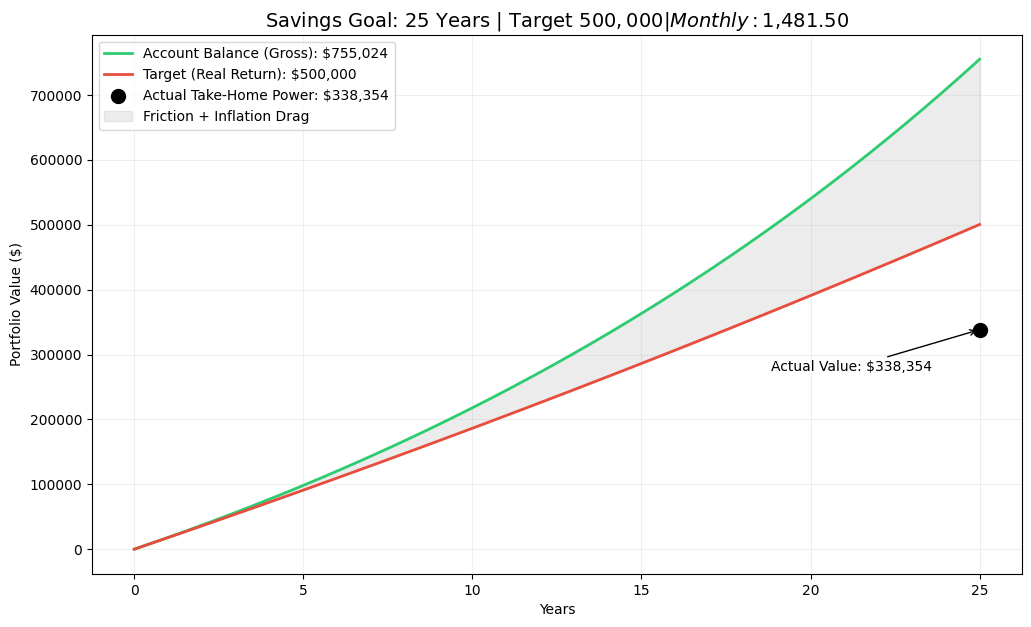


Final Reality Check at Year 25:
To have $500,000 in REAL buying power, you must save $1,481.50 monthly.
Your final account balance will show: $755,023.73
After paying $46,586.26 in tax, your actual buying power today is: $338,353.68


In [ ]:
def run_post_tax_reality_check():
    # 1. USER INPUTS (Percentages as Integers)
    X = float(input("Target Amount(e.g., 100K, 500K): "))
    T = float(input("Number of Years (e.g., 40): "))

    r_gross_int = float(input("Annual Gross Return %: "))
    inf_int = float(input("Annual Inflation %: "))
    exp_int = float(input("ETF Expense Ratio %: "))
    turn_int = float(input("ETF Turnover Rate %: "))
    tax_rate_int = float(input("Capital Gains Tax % (e.g., 15): "))

    # CONVERSIONS
    r_gross, inf, exp, turn, tax_rate = [v/100 for v in [r_gross_int, inf_int, exp_int, turn_int, tax_rate_int]]
    fric = turn * 0.0041
    total_drag = inf + exp + fric

    # Real Rate calculation for monthly savings (y)
    annual_real_rate = ((1 + r_gross) / (1 + total_drag)) - 1
    monthly_real_rate = (1 + annual_real_rate)**(1/12) - 1
    total_months = int(T * 12)

    # CALCULATE REQUIRED SAVINGS (y)
    y = (X * monthly_real_rate) / ((1 + monthly_real_rate)**total_months - 1)

    # SIMULATION
    months = np.arange(total_months + 1)
    monthly_nominal_rate = (1 + (r_gross - exp - fric))**(1/12) - 1

    gross_bal, real_bal, cumulative_invested = [0.0], [0.0], [0.0]
    for m in range(1, total_months + 1):
        gross_bal.append((gross_bal[-1] + y) * (1 + monthly_nominal_rate))
        real_bal.append((real_bal[-1] + y) * (1 + monthly_real_rate))
        cumulative_invested.append(cumulative_invested[-1] + y)

    # THE REALITY CHECK AT YEAR T
    final_gross = gross_bal[-1]
    total_in = cumulative_invested[-1]
    taxable_gain = max(0, final_gross - total_in)
    tax_due = taxable_gain * tax_rate

    # Final 'Cash-In-Hand' after tax
    post_tax_nominal = final_gross - tax_due
    # Today's Buying Power of that post-tax cash
    actual_take_home_real = post_tax_nominal / ((1 + inf)**T)

    # VISUALIZE
    plt.figure(figsize=(12, 7))
    plt.plot(months/12, gross_bal, label=f'Account Balance (Gross): ${final_gross:,.0f}', color='#2ecc71', lw=2)
    plt.plot(months/12, real_bal, label=f'Target (Real Return): ${X:,.0f}', color='#e74c3c', lw=2)

    # Add a marker for the final "Actual" purchasing power
    plt.scatter(T, actual_take_home_real, color='black', s=100, zorder=5, label=f'Actual Take-Home Power: ${actual_take_home_real:,.0f}')
    plt.annotate(f'Actual Value: ${actual_take_home_real:,.0f}', (T, actual_take_home_real),
                 xytext=(-150, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

    plt.fill_between(months/12, real_bal, gross_bal, color='gray', alpha=0.15, label='Friction + Inflation Drag')
    plt.title(f"Savings Goal: {int(T)} Years | Target ${X:,.0f} | Monthly : ${y:,.2f}", fontsize=14)
    plt.xlabel("Years")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"\nFinal Reality Check at Year {int(T)}:")
    print(f"To have ${X:,.0f} in REAL buying power, you must save ${y:,.2f} monthly.")
    print(f"Your final account balance will show: ${final_gross:,.2f}")
    print(f"After paying ${tax_due:,.2f} in tax, your actual buying power today is: ${actual_take_home_real:,.2f}")

run_post_tax_reality_check()


tax-adjusted monthly savings:

REALITY CHECK: TAX-ADJUSTED SAVINGS CALCULATOR
Target Amount in today's buying power: 500000
Number of Years: 25
Expected Annual Gross Return % (e.g., 7): 7
Annual Inflation % (e.g., 3): 3
ETF Expense Ratio % (e.g., 3): 3
ETF Turnover Rate % (e.g., 2): 3
Capital Gains Tax % (e.g., 15): 15


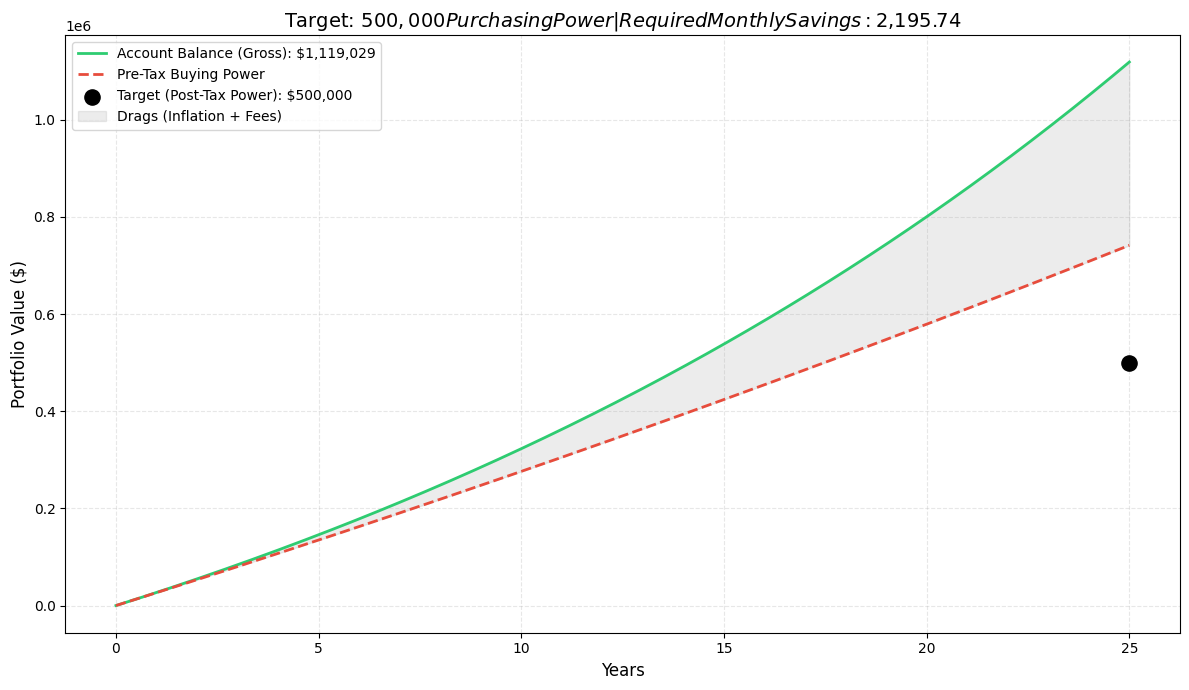


 FINAL RESULTS AT YEAR 25 
Monthly Savings Required:      $2,195.74
Total Invested (Out of Pocket):$658,722.49
Final Account Balance:         $1,119,029.40
Capital Gains Tax Due:         $69,046.04
Actual Post-Tax Value:         $1,049,983.36
Actual Purchasing Power:       $501,477.90 (Target Achieved)
----------------------------------------
The 'System' (Inf/Fees/Tax) took $617,551.50 of your nominal growth.


In [ ]:
def run_final_tax_adjusted_simulator():
    print("REALITY CHECK: TAX-ADJUSTED SAVINGS CALCULATOR")

    #USER INPUTS (Percentages as Integers)
    try:
        X = float(input("Target Amount in today's buying power: "))
        T = float(input("Number of Years: "))

        r_g_int = float(input("Expected Annual Gross Return % (e.g., 7): "))
        inf_int = float(input("Annual Inflation % (e.g., 3): "))
        exp_int = float(input("ETF Expense Ratio % (e.g., 3): "))
        turn_int = float(input("ETF Turnover Rate % (e.g., 2): "))
        tax_int = float(input("Capital Gains Tax % (e.g., 15): "))
    except ValueError:
        print("Invalid input. Please enter numbers only.")
        return

    # CONVERSION TO DECIMALS
    r_g = r_g_int / 100
    inf = inf_int / 100
    exp = exp_int / 100
    turn = turn_int / 100
    tax = tax_int / 100

    # Internal friction (0.41% per 100% turnover)
    fric = turn * 0.0041
    months = int(T * 12)

    # Net Nominal Rate (Market growth minus fund fees)
    net_nom_annual = r_g - exp - fric
    m_nom = (1 + net_nom_annual)**(1/12) - 1

    # ITERATIVE SOLVER FOR y
    # We solve for y where: (Gross_Balance - Tax) / (1 + inf)^T = X
    y_adj = X / months  # Initial guess
    for _ in range(100):
        # Calculate nominal balance at end of T
        gross_bal = (y_adj * ((1 + m_nom)**months - 1)) / m_nom

        # Calculate tax on nominal gains (Gross - Total Invested)
        total_invested = y_adj * months
        taxable_gain = max(0, gross_bal - total_invested)
        tax_due = taxable_gain * tax

        # Determine actual purchasing power of the remaining cash
        actual_purchasing_power = (gross_bal - tax_due) / ((1 + inf)**T)

        # Adjust y based on the ratio of target to current result
        if actual_purchasing_power > 0:
            y_adj *= (X / actual_purchasing_power)

    # SIMULATE HISTORICAL DATA FOR PLOTTING
    m_axis = np.arange(months + 1)
    # Real rate including inflation for the dashed line
    m_real_annual = ((1 + r_g) / (1 + inf + exp + fric)) - 1
    m_real = (1 + m_real_annual)**(1/12) - 1

    gross_history = [0.0]
    real_history = [0.0]

    for m in range(1, months + 1):
        gross_history.append((gross_history[-1] + y_adj) * (1 + m_nom))
        real_history.append((real_history[-1] + y_adj) * (1 + m_real))

    final_gross = gross_history[-1]
    final_tax = (final_gross - (y_adj * months)) * tax
    final_post_tax_cash = final_gross - final_tax
    final_buying_power = final_post_tax_cash / ((1 + inf)**T)

    # VISUALIZE RESULTS
    plt.figure(figsize=(12, 7))

    # Green Line: What your bank statement shows
    plt.plot(m_axis/12, gross_history, label=f'Account Balance (Gross): ${final_gross:,.0f}', color='#2ecc71', lw=2)

    # Red Dashed: Pre-tax purchasing power (Internal fund drag + inflation)
    plt.plot(m_axis/12, real_history, label='Pre-Tax Buying Power', color='#e74c3c', linestyle='--', lw=2)

    # Black Dot: Actual Post-Tax purchasing power (Target X)
    plt.scatter(T, X, color='black', s=120, zorder=5, label=f'Target (Post-Tax Power): ${X:,.0f}')

    # Shading the "Theft" gap
    plt.fill_between(m_axis/12, real_history, gross_history, color='gray', alpha=0.15, label='Drags (Inflation + Fees)')

    plt.title(f"Target: ${X:,.0f} Purchasing Power | Required Monthly Savings: ${y_adj:,.2f}", fontsize=14)
    plt.xlabel("Years", fontsize=12)
    plt.ylabel("Portfolio Value ($)", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # PRINT SUMMARY
    print(f"\n FINAL RESULTS AT YEAR {int(T)} ")
    print(f"Monthly Savings Required:      ${y_adj:,.2f}")
    print(f"Total Invested (Out of Pocket):${(y_adj * months):,.2f}")
    print(f"Final Account Balance:         ${final_gross:,.2f}")
    print(f"Capital Gains Tax Due:         ${final_tax:,.2f}")
    print(f"Actual Post-Tax Value:         ${final_post_tax_cash:,.2f}")
    print(f"Actual Purchasing Power:       ${final_buying_power:,.2f} (Target Achieved)")
    print("-" * 40)
    print(f"The 'System' (Inf/Fees/Tax) took ${(final_gross - final_buying_power):,.2f} of your nominal growth.")

# To run the simulation
run_final_tax_adjusted_simulator()
